# Client personality analysis
Author: David Moncivais | August 4 2026 | Data: [Customer Personality Analysis](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)

## Introduction

### Objective
The objective of this project is to use the available data — a list of customers with different attributes — and cluster the information to summarize customer segments. A secondary objective, as with previous projects, is to use it as a practice exercise for data presentation, feature engineering, model selection, hyperparameter tuning, and the interpretation of results through data visualization.

Customer personality analysis helps a business to modify its product based on its target customers from different types of customer segments. For example, instead of spending money to market a new product to every customer in the company’s database, a company can analyze which customer segment is most likely to buy the product and then market the product only on that particular segment.  It helps a business to better understand its customers and makes it easier for them to modify products according to the specific needs, behaviors and concerns of different types of customers. 

### The data
The data is a dataset of 2240 rows of individual customers, where each feature column is part of a simplified group of characteristics for each customer. The groups are: People, Products, Promotion, and Place. The dataset description give use the next glossary of the columns needed to look at for the experiment:
- People
    - ID: Customer's unique identifier
    - Year_Birth: Customer's birth year
    - Education: Customer's education level
    - Marital_Status: Customer's marital status
    - Income: Customer's yearly household income
    - Kidhome: Number of children in customer's household
    - Teenhome: Number of teenagers in customer's household
    - Dt_Customer: Date of customer's enrollment with the company
    - Recency: Number of days since customer's last purchase
    - Complain: 1 if the customer complained in the last 2 years, 0 otherwise
- Products
    - MntWines: Amount spent on wine in last 2 years
    - MntFruits: Amount spent on fruits in last 2 years
    - MntMeatProducts: Amount spent on meat in last 2 years
    - MntFishProducts: Amount spent on fish in last 2 years
    - MntSweetProducts: Amount spent on sweets in last 2 years
    - MntGoldProds: Amount spent on gold in last 2 years
- Promotion
    - NumDealsPurchases: Number of purchases made with a discount
    - AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise
    - AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
    - AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
    - AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise
    - AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise
    - Response: 1 if customer accepted the offer in the last campaign, 0 otherwise
- Place
    - NumWebPurchases: Number of purchases made through the company’s website
    - NumCatalogPurchases: Number of purchases made using a catalogue
    - NumStorePurchases: Number of purchases made directly in stores
    - NumWebVisitsMonth: Number of visits to company’s website in the last month

## Data exploration

Before starting, here are the libraries needed for the data exploration portion of this project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import math

Next is the reading of the data and capturing the features previously mentioned in the introduction. There are more features that are not mentioned but still exist in the data, but since the same page doesn't give me an explanation of what they are, I decided not to take them into account and stick with what I know. Since this dataset doesn't come with information on how many data entries it has, I decided to add a little line to check this.

In [2]:
base_columns = ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'Complain', 'MntWines', 'MntFruits',
                'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 
                'AcceptedCmp5', 'Response', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
df = pd.read_csv('./Data/marketing_campaign.csv', sep='\t')[base_columns]
print('Number of columns: ' + str(len(base_columns)) + '\nNumber of data entries: ' + str(len(df['ID'])))

Number of columns: 26
Number of data entries: 2240


We can see here that the number of columns it gives us is 26 in total, and the total number of data entries is 2240 — a little low, but let's try to make it work to continue this project. Next it's a showcase of how each column is presented in the dataset, next the decription of this one and finally some info about each feature:

In [3]:
for i in range(3):
    display(df[base_columns[i*9:(i*9)+9]].head(5))

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,Complain
0,5524,1957,Graduation,Single,58138.0,0,0,58,0
1,2174,1954,Graduation,Single,46344.0,1,1,38,0
2,4141,1965,Graduation,Together,71613.0,0,0,26,0
3,6182,1984,Graduation,Together,26646.0,1,0,26,0
4,5324,1981,PhD,Married,58293.0,1,0,94,0


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,AcceptedCmp1,AcceptedCmp2
0,635,88,546,172,88,88,3,0,0
1,11,1,6,2,1,6,2,0,0
2,426,49,127,111,21,42,1,0,0
3,11,4,20,10,3,5,2,0,0
4,173,43,118,46,27,15,5,0,0


,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,0,0,0,1,8,10,4,7
1,0,0,0,0,1,1,2,5
2,0,0,0,0,8,2,10,4
3,0,0,0,0,2,0,4,6
4,0,0,0,0,5,3,6,5


In [4]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,Complain,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,0.009375,303.935714,26.302232,166.950000,...,0.064286,0.013393,0.072768,0.074554,0.072768,0.149107,4.084821,2.662054,5.790179,5.316518
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,0.096391,336.597393,39.773434,225.715373,...,0.245316,0.114976,0.259813,0.262728,0.259813,0.356274,2.778714,2.923101,3.250958,2.426645
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,0.000000,23.750000,1.000000,16.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000,3.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,0.000000,173.500000,8.000000,67.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2.000000,5.000000,6.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,0.000000,504.250000,33.000000,232.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,8.000000,7.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1.000000,1493.000000,199.000000,1725.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,27.000000,28.000000,13.000000,20.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Recency              2240 non-null   int64  
 8   Complain             2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

First, we can see that some features are boolean in nature, like whether there are kids or teens at home, whether they have ever complained, or in what campaign the client accepted an offer. We also have a very general view of the purchase history of each client, showing the number of articles purchased for each category. The number of articles bought can range from not buying a single one to buying 1725 or 1493, depending on the type of article. Finally, we can observe which purchase method performs better. In this case, in-store purchases win with an average of about 5.79 purchases per customer, followed by web purchases (\~4.08) and catalog purchases (\~2.66). Store purchases also show the widest range, reaching up to 13 purchases, compared to 27 for web and 28 for catalog — meaning that while store is the most consistent method, a few customers show unusually high activity through web and catalog purchases.

After that table we have another one for seeing if any of the features presented have null entries. In this case one does, 'Income' has 2216 non-null values out of 2240 lines of data. Let's see what percentage is missing:

In [6]:
df[['Income']].isnull().mean() * 100

Income    1.071429
dtype: float64

1% isn't much, let's add code to fill those incomes with the median of the column based on the education group of each customer, just so it doesn't skew our analysis:

In [7]:
df['Income'] = df.groupby('Education')['Income'].transform(lambda x: x.fillna(x.median()))
df[['Income']].isnull().mean() * 100

Income    0.0
dtype: float64

Once we have that under control, as a matter of personal preference I'll change one variable and group several others. The Year_Birth feature will be substituted for one called 'Age', since it's easier to read and understand. The group of variables 'AcceptedCmp' and 'Response' will be substituted into one single feature called 'Campaign', since all variables are of boolean type, indicating whether the client accepted an offer in one of the 6 campaigns. It seems easier to create a feature called 'Campaign' and store the number (1 to 6) depending on which campaign an offer was accepted, and 0 if the client hasn't accepted anything.

In [8]:
i = 0
r_camp = []
r_age = []
for row in df.itertuples():
    try: r_camp.append(row[18:24].index(1)+1)
    except: r_camp.append(0)
    r_age.append(2026 - int(row[2]))
df['campaign'] = r_camp
df['Age'] = r_age
df = df.drop(['Year_Birth'], axis=1)
df = df.drop(['AcceptedCmp'+str(i) for i in range(1,6)]+['Response'], axis=1)
df.head(3)

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,Complain,MntWines,MntFruits,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,campaign,Age
0,5524,Graduation,Single,58138.0,0,0,58,0,635,88,...,172,88,88,3,8,10,4,7,5,69
1,2174,Graduation,Single,46344.0,1,1,38,0,11,1,...,2,1,6,2,1,1,2,5,6,72
2,4141,Graduation,Together,71613.0,0,0,26,0,426,49,...,111,21,42,1,8,2,10,4,0,61


Here we can see that the last function worked, and we now have the 2 new features to reduce the other 7.

Next, I developed 2 functions to help with the next section of the data exploration. The basic idea is to graph the clients' personal data against customer characteristics (amount of each product bought and how they bought it). Since most of it will be repetition of code, it's better to put it all in functions so it's easier for the reader later on. Both will present percentages of a total. The only difference is that the first one works with ranges of numbers as well as categorical labels for x, while the second one works for displaying (if applicable) a larger, more detailed set without ranges — showing every single unique value of x.

In [9]:
def distribution_graph_simple(df: pd.DataFrame, x_label: str = '', y_label: list[str] = ['']):
    df_pct_avg = 0
    df_pct = df[y_label].div(df[y_label].sum(axis=1), axis=0) * 100
    if pd.api.types.is_numeric_dtype(df[x_label]):
        options = {1: 5, 2: 50, 3: 500, 4: 5000, 5:50000}
        inter = options[math.floor(math.log10(max(df[x_label])))]
        b_min = int(min(df[x_label]))
        b_max = max(df[x_label]) % inter
        b_max = int(max(df[x_label]) if b_max == 0 else max(df[x_label]) + (inter - b_max))
        lst_bin = [i for i in range(b_min, b_max+1, inter)]
        bins = pd.cut(df[x_label], bins=lst_bin, right=False)
        df_pct_avg = df_pct.groupby(bins).mean().reset_index()
    else:
        df_pct_avg = df_pct.groupby(df[x_label]).mean().reset_index()

    bottom = None
    plt.figure(figsize=(13,8))
    for col in y_label:
        bars = plt.bar(df_pct_avg[x_label].astype(str), df_pct_avg[col], bottom=bottom, label=col)
        for bar, val, b in zip(bars, df_pct_avg[col], bottom if bottom is not None else [0]*len(bars)):
            plt.text(bar.get_x()+bar.get_width()/2, b+val/2, f'{val:.0f}%', ha='center', va='center', fontsize=8)
        if bottom is None:
            bottom = df_pct_avg[col].copy()
        else:
            bottom += df_pct_avg[col]
    
    plt.yticks([i for i in range(5,101,5)])
    
    plt.xlabel('Ranges of ' + x_label)
    plt.ylabel('% of total amount')
    if x_label == 'Age':
        plt.title('According to ' + x_label + ', What is what clients want? (Ranges)')
    else:
        plt.title('According to ' + x_label + ', What is what clients want?')
        
    plt.legend()
    plt.show()

def distribution_graph_detailed(df: pd.DataFrame(), x_label: str = '', y_label: list[str] = ['']):
    df_pct = df[y_label].div(df[y_label].sum(axis=1), axis=0) * 100
    df_pct_avg = df_pct.groupby(df[x_label]).mean().reset_index()

    bottom = None
    plt.figure(figsize=(13,8))
    for col in y_label:
        plt.bar(df_pct_avg[x_label], df_pct_avg[col], bottom=bottom, label=col)
        if bottom is None:
            bottom = df_pct_avg[col].copy()
        else:
            bottom += df_pct_avg[col]
    
    plt.yticks([i for i in range(5,101,5)])
    
    plt.xlabel(x_label)
    plt.ylabel('% of total amount')
    plt.title('According to ' + x_label + ', What is what clients want?')

    plt.legend()
    plt.show()

Here are the unique values of the categorical value presented in this data set. The first one is the education level a client have and the second the marital status of the same one.

In [22]:
df['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

From what I could gather, since I only know 'high school diploma', 'Bachelor's', 'Master's', and 'PhD', Graduation is the same as a Bachelor's, Basic is like a high school diploma, and 2nd Cycle is something like a postgraduate degree in the European education system.

In [23]:
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In this one, apart from the first 5 that are typical, we have 'Alone', 'Absurd', and 'YOLO', and being that I just happen to be leaving my 'Young' phase behind, I could infer the following:
- Alone means that the person simply doesn't see themself in a relationship (just like single, but with more emphasis on the "single" part).
- Absurd is either a way of saying that this person sees the question as trying to put them inside a box they don't feel they fit in, or that they don't fully understand their current situationship.
- And 'YOLO' I think can only be described as a way of describing a person who isn't going to be tied down to anyone.

In [12]:
df_clients_age = df[['Age', 'Income']].groupby('Age', as_index = False).count()
display(df_clients_age[df_clients_age['Income'] > 1].rename(columns = {"Income": 'Count'}).sort_values('Age'))

,Age,Count
0,30,2
1,31,5
2,32,3
3,33,5
4,34,13
5,35,15
6,36,18
7,37,30
8,38,29
9,39,27


In [13]:
df_sort = df.sort_values(by = 'Age')[df['Age'] <100]
print('Youngest client: ' + str(df_sort['Age'].iloc[0]) + ', Oldest client: ' + str(df_sort['Age'].iloc[-1]))
df_sort.head(3)

Youngest client: 30, Oldest client: 86


C:\Users\david\AppData\Local\Temp\ipykernel_31608\1444714999.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_sort = df.sort_values(by = 'Age')[df['Age'] <100]


,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,Complain,MntWines,MntFruits,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,campaign,Age
46,9909,2n Cycle,Married,7500.0,0,0,24,0,3,18,...,15,22,50,3,3,1,3,9,5,30
1170,193,Basic,Married,14421.0,0,0,81,0,0,0,...,3,3,8,1,1,0,2,5,2,30
2213,3661,2n Cycle,Single,80617.0,0,0,42,0,594,51,...,72,55,32,1,4,6,8,2,0,31


In [14]:
cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_sort[['Age'] + cols].head(5)

,Age,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
46,30,3,18,14,15,22,50
1170,30,0,0,2,3,3,8
2213,31,594,51,631,72,55,32
747,31,283,17,372,138,106,44
1850,31,536,27,590,38,107,67


C:\Users\david\AppData\Local\Temp\ipykernel_31608\2998428750.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pct_avg = df_pct.groupby(bins).mean().reset_index()


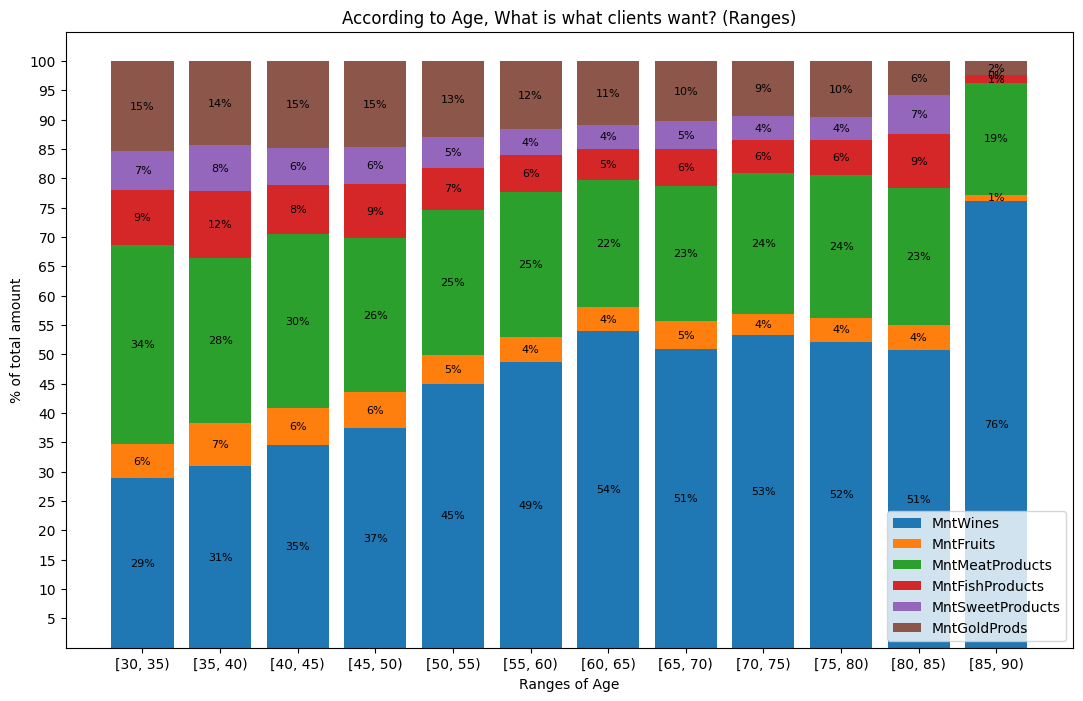

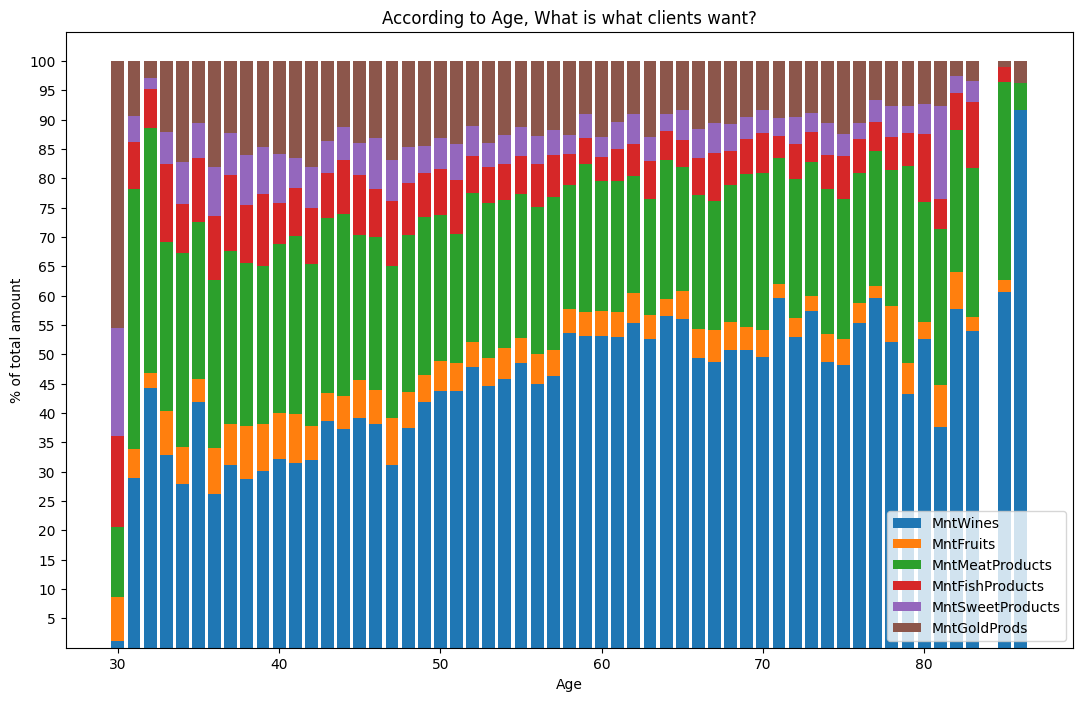

In [15]:
distribution_graph_simple(df_sort, 'Age', cols)
distribution_graph_detailed(df_sort, 'Age', cols)

C:\Users\david\AppData\Local\Temp\ipykernel_31608\2998428750.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pct_avg = df_pct.groupby(bins).mean().reset_index()


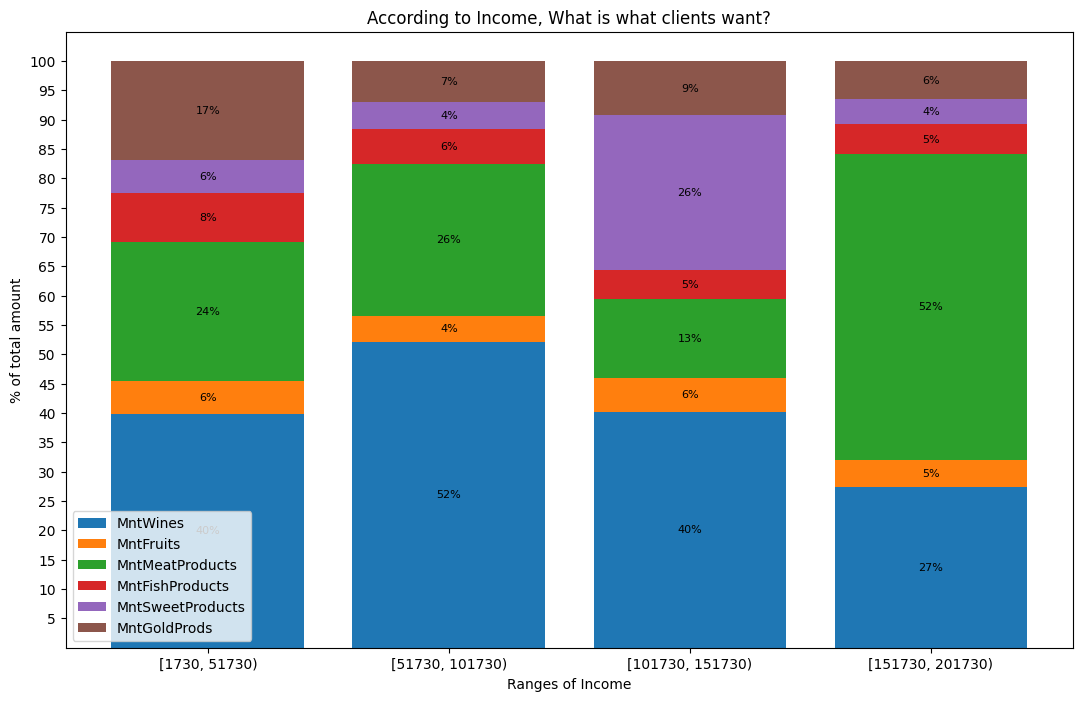

In [16]:
distribution_graph_simple(df_sort, 'Income', cols)

In [17]:
cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df[['Age'] + cols].head(5)

,Age,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
0,69,8,10,4
1,72,1,1,2
2,61,8,2,10
3,42,2,0,4
4,45,5,3,6


C:\Users\david\AppData\Local\Temp\ipykernel_31608\2998428750.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pct_avg = df_pct.groupby(bins).mean().reset_index()


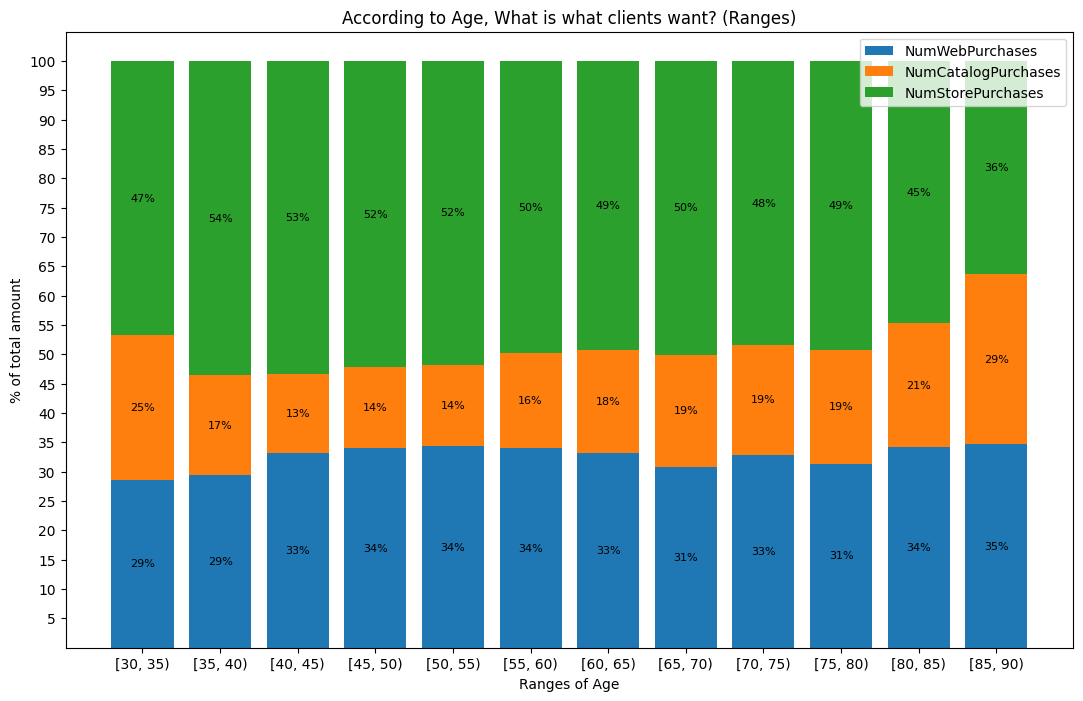

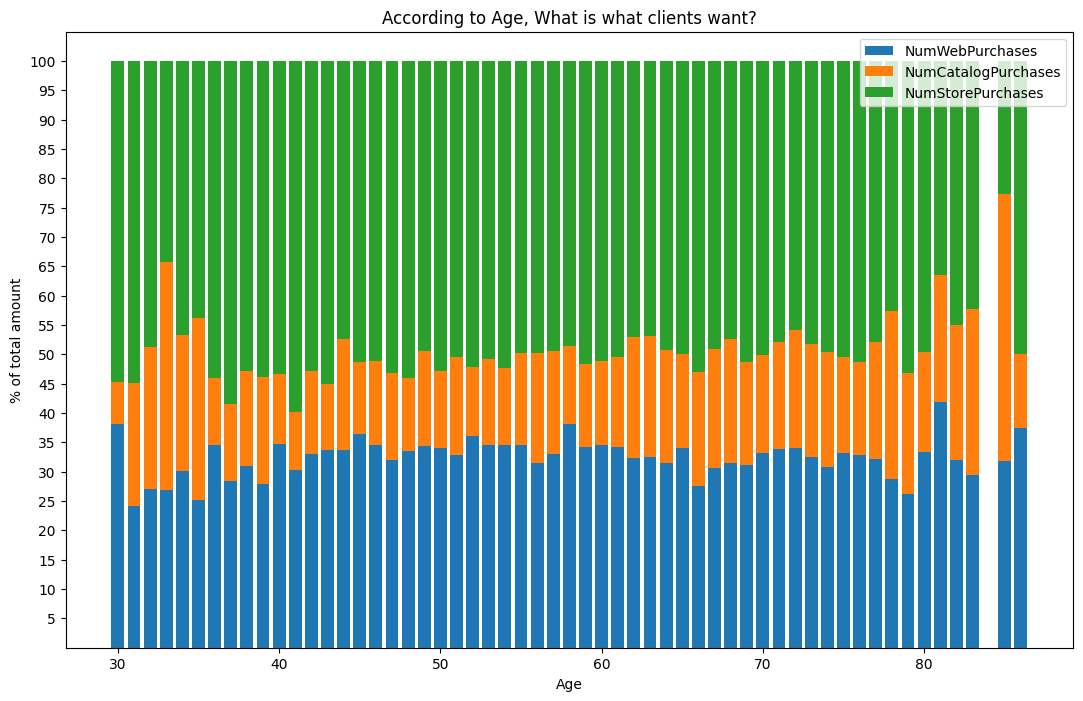

In [18]:
distribution_graph_simple(df_sort, 'Age', cols)
distribution_graph_detailed(df_sort, 'Age', cols)

C:\Users\david\AppData\Local\Temp\ipykernel_31608\2998428750.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pct_avg = df_pct.groupby(bins).mean().reset_index()


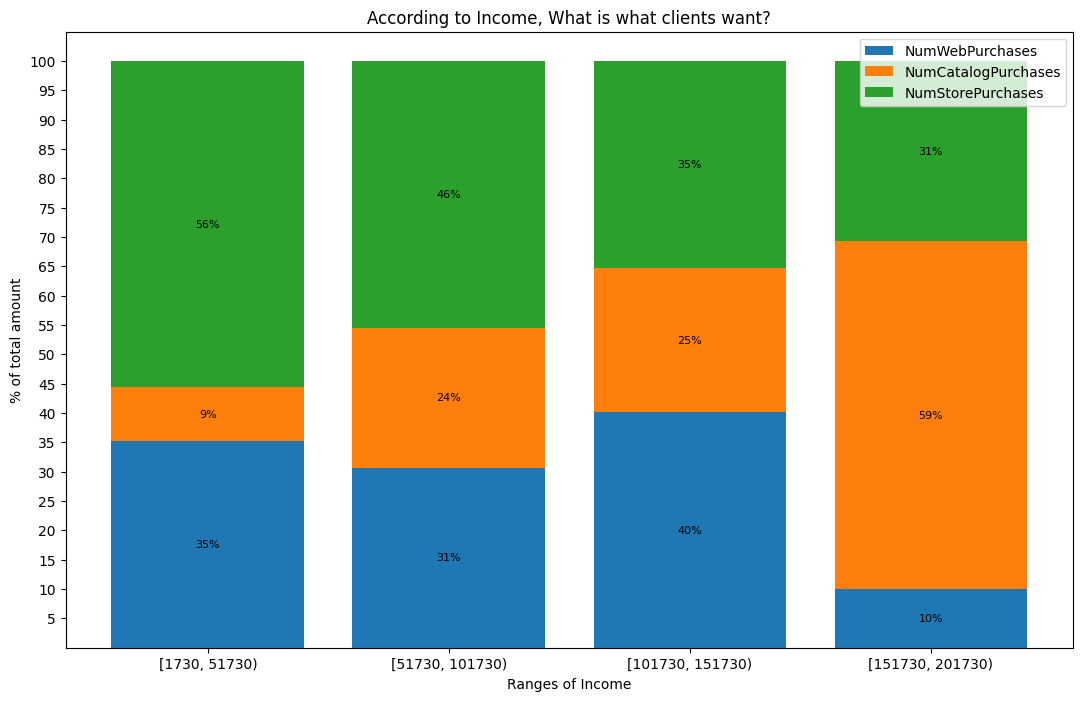

In [19]:
distribution_graph_simple(df_sort, 'Income', cols)

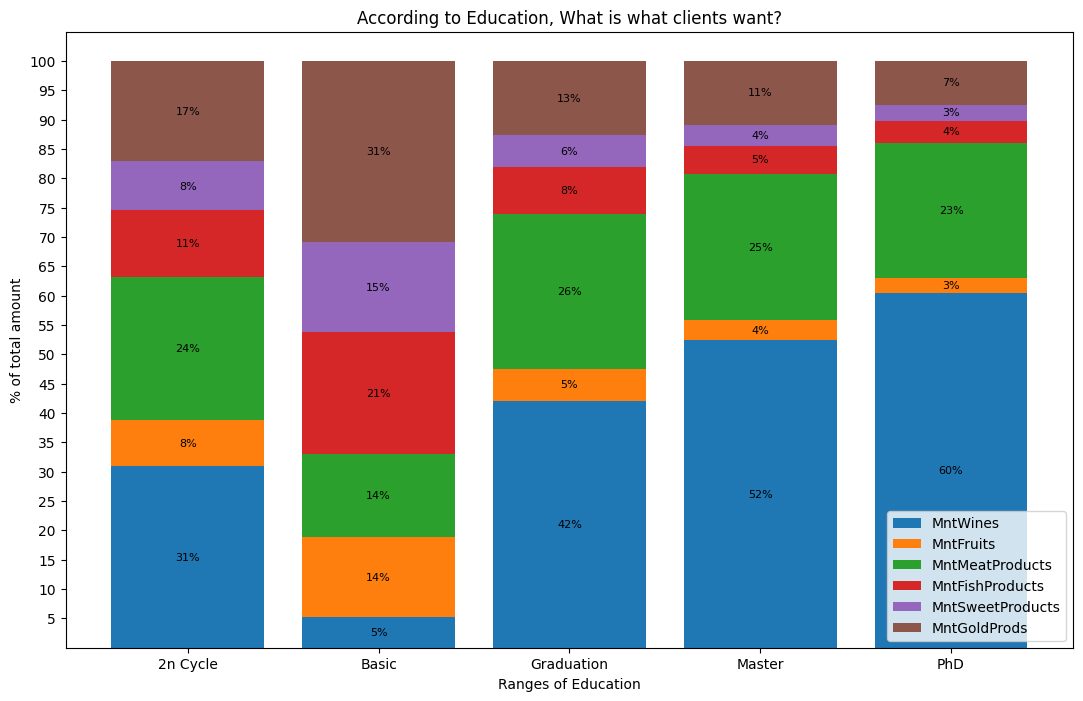

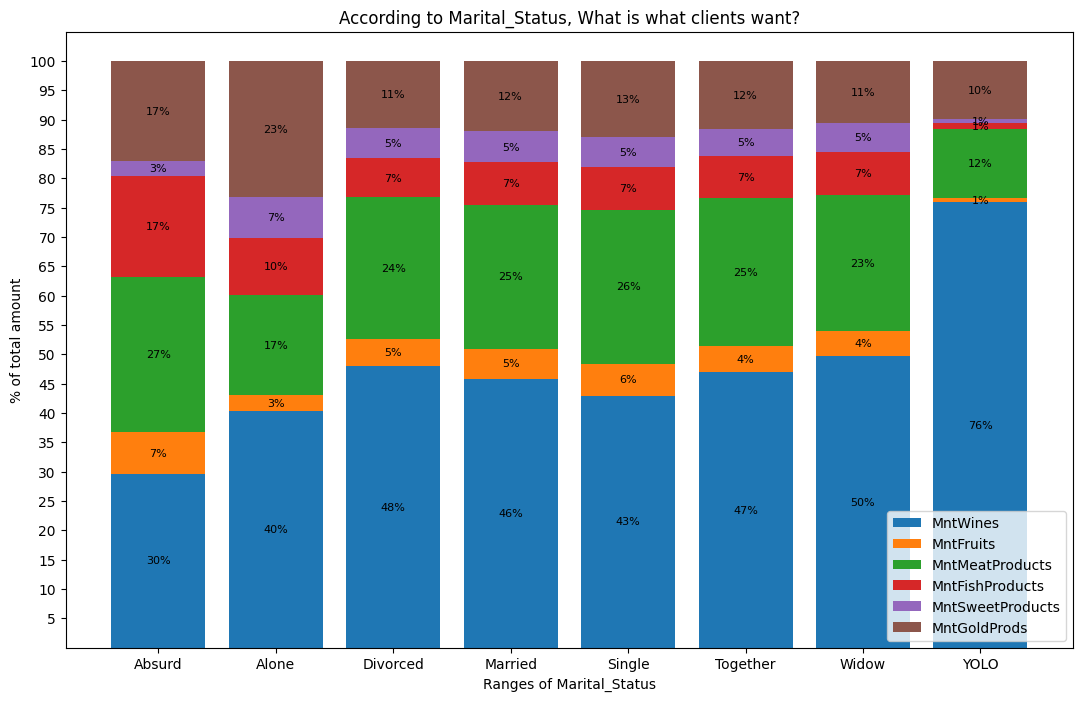

In [20]:
cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
distribution_graph_simple(df_sort, 'Education', cols)
distribution_graph_simple(df_sort, 'Marital_Status', cols)

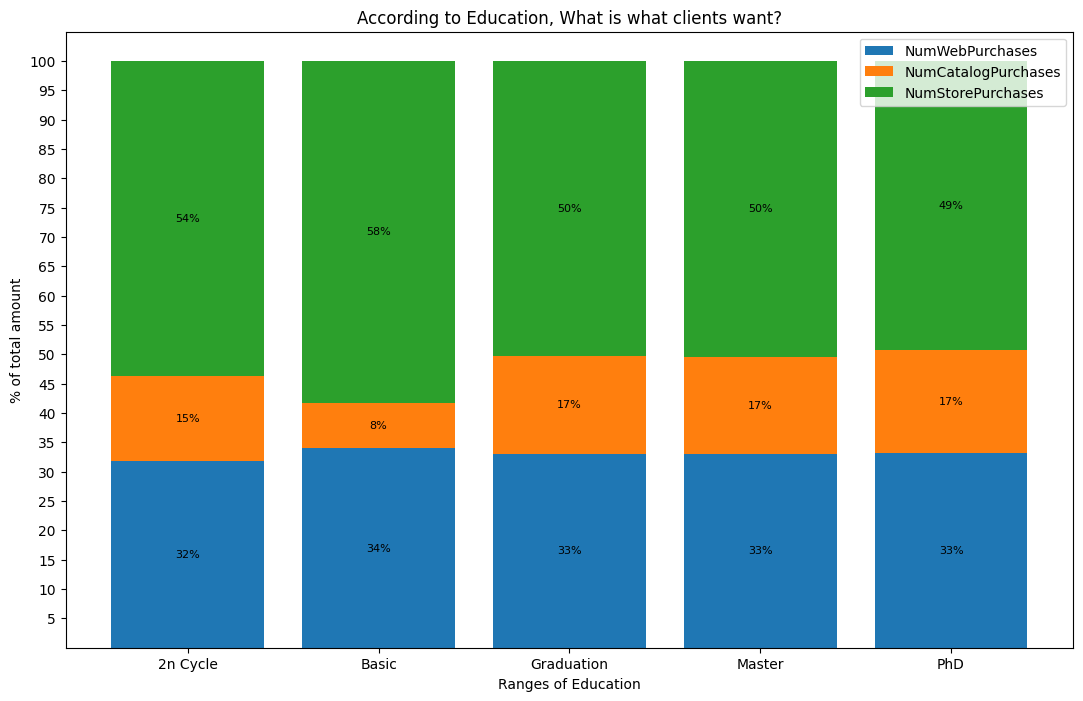

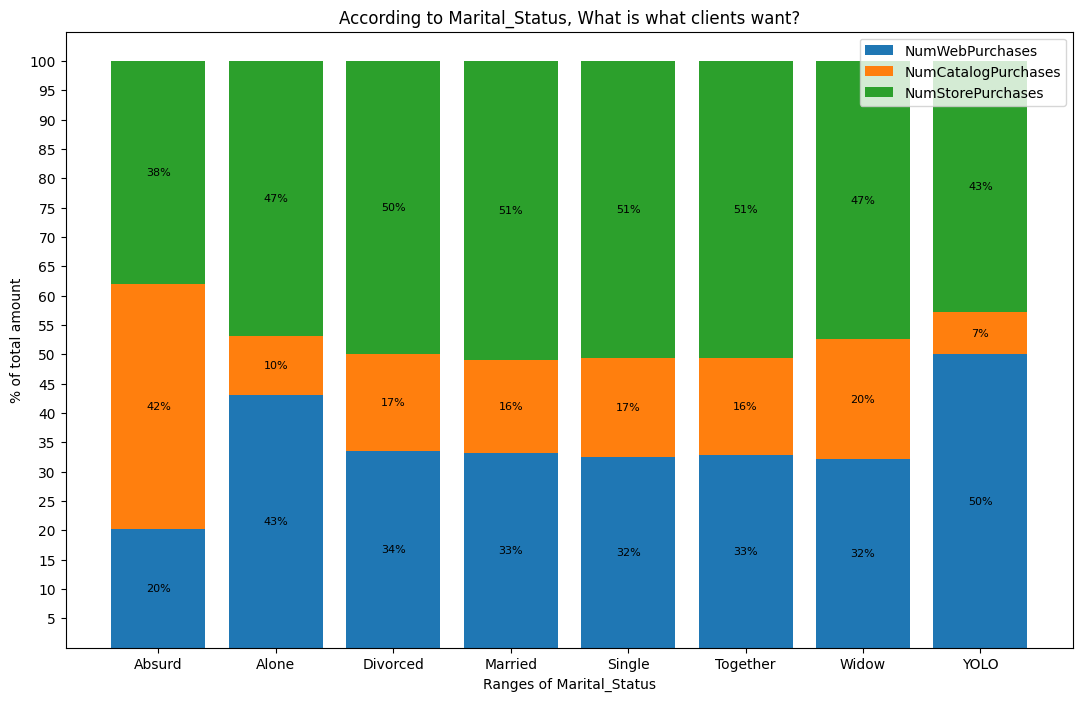

In [21]:
cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
distribution_graph_simple(df_sort, 'Education', cols)
distribution_graph_simple(df_sort, 'Marital_Status', cols)